# PDA-4. SciPy. Статистические тесты

## 1. Введение. Статистические тесты

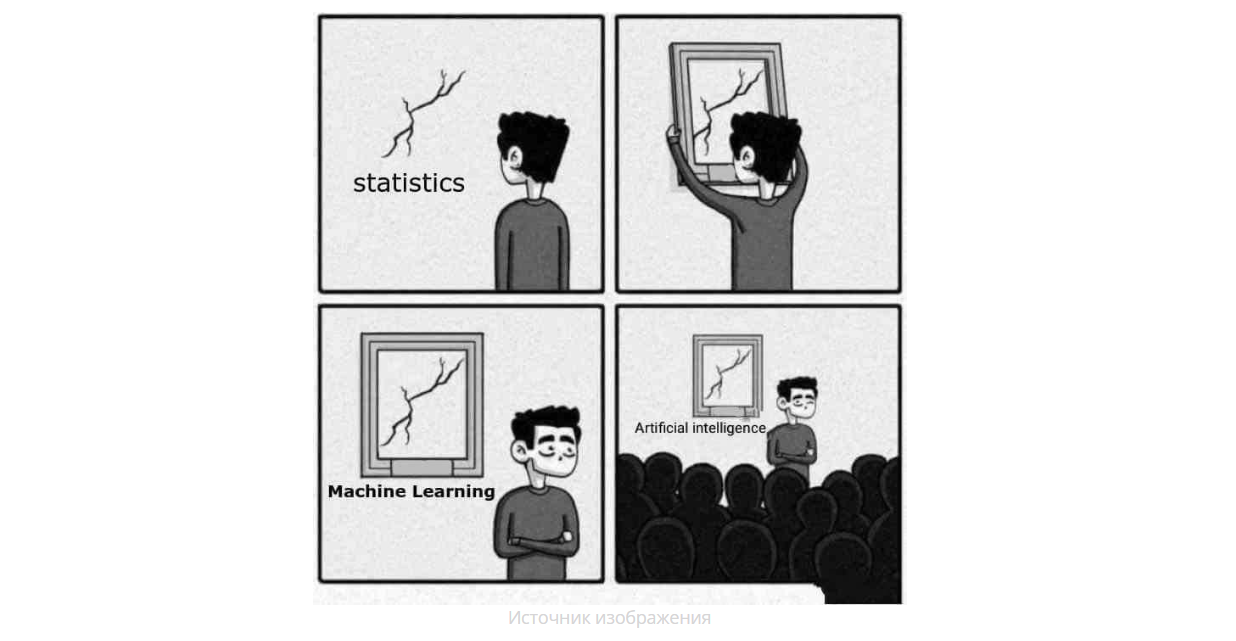

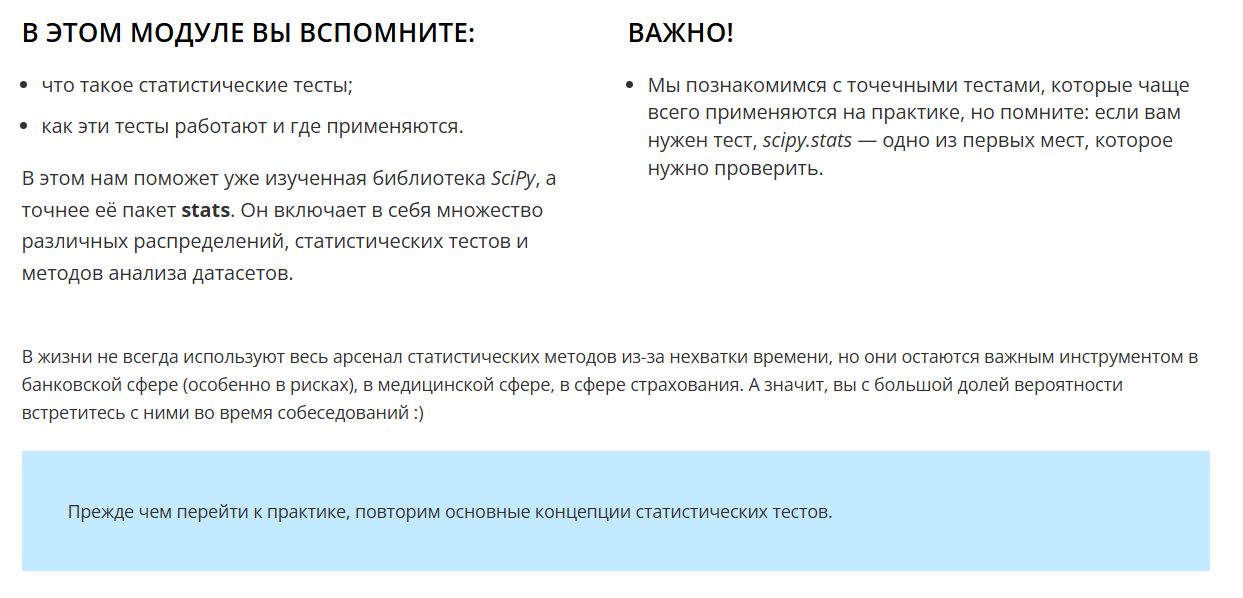

# 2. Основные концепции статистических тестов

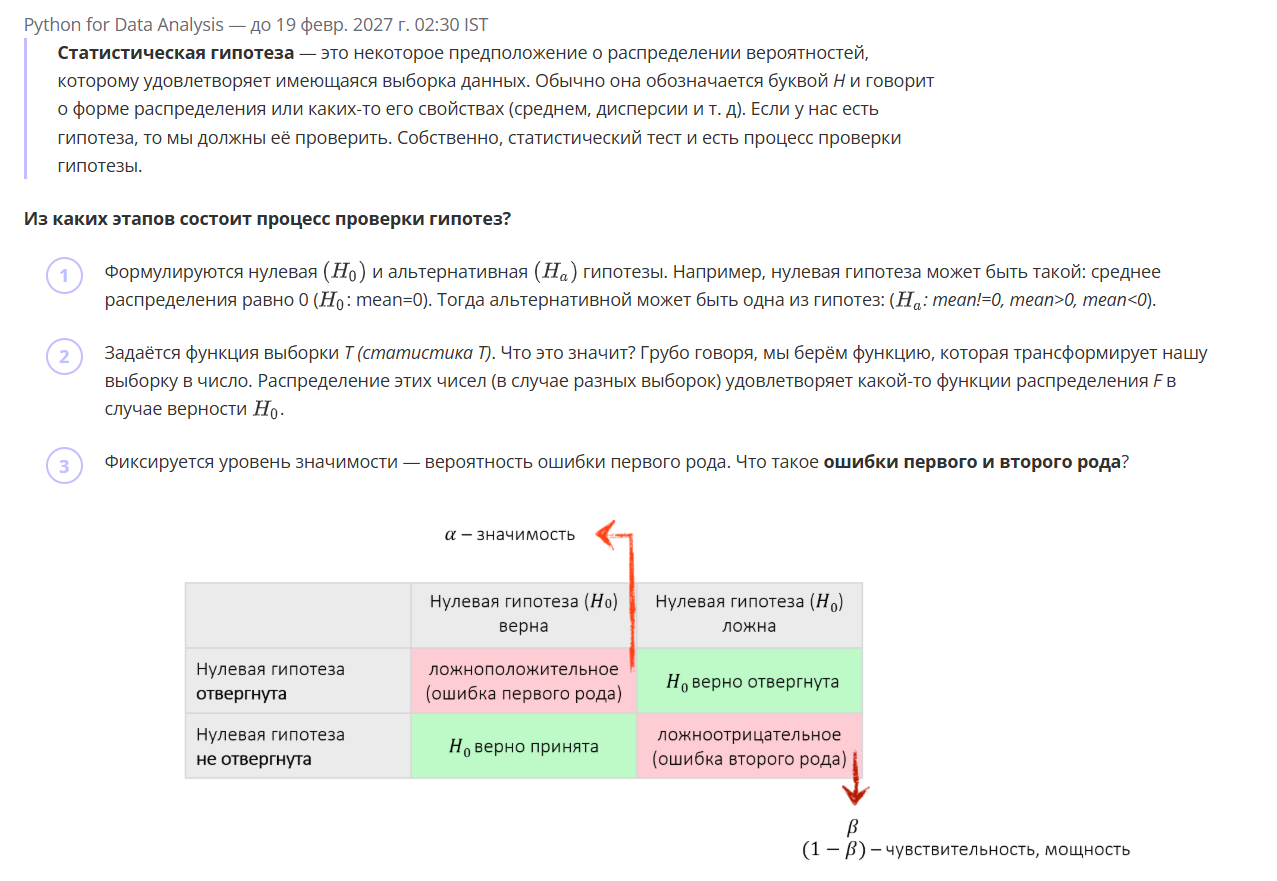

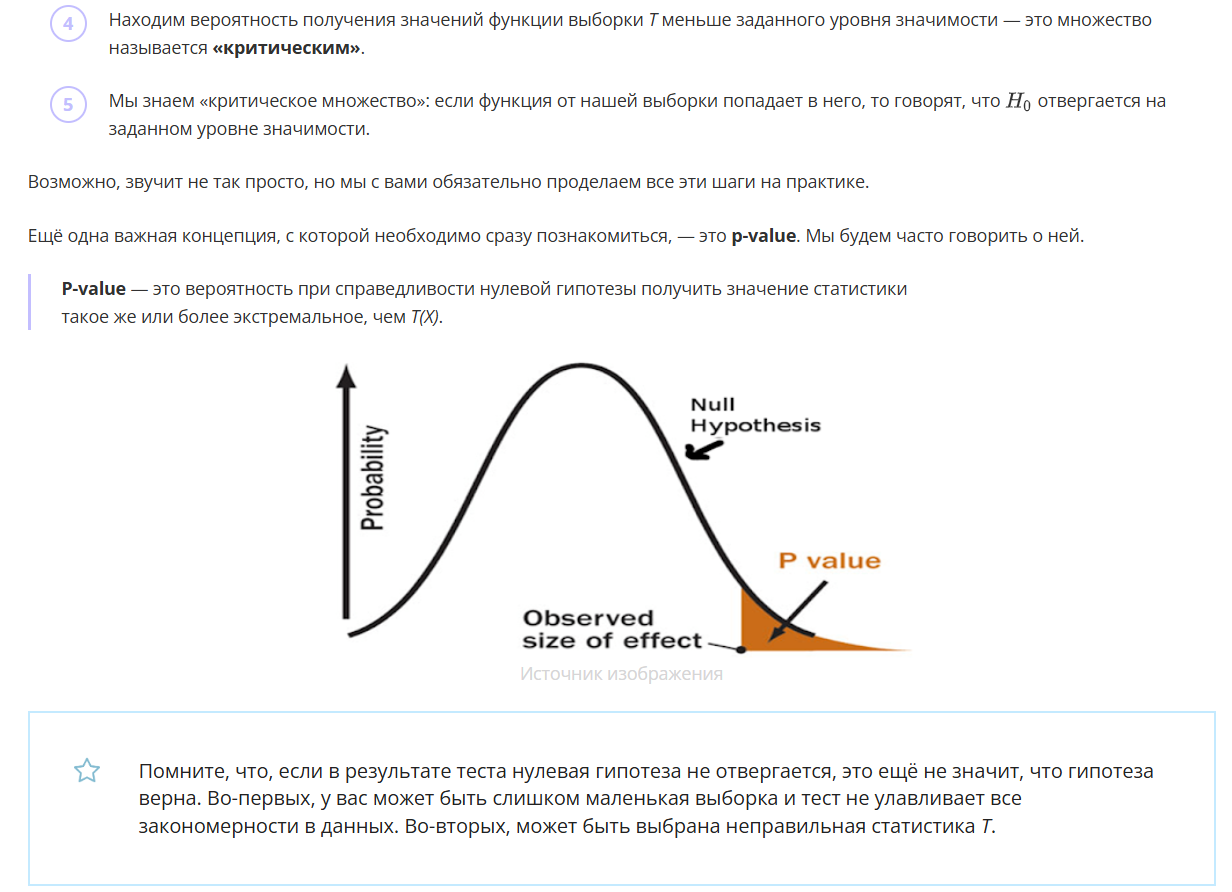

Существует очевидный способ борьбы с первой причиной — найти больше данных. Вторая проблема сложнее, она требует использования более мощных критериев, но в рамках курса мы не столкнёмся с такими кейсами.

Что ж, мы с вами вспомнили теорию статистических тестов. Самое время перейти к самим тестам и их применению!

# 3. Статистические тесты и применимость методов машинного обучения к задачам

Прежде чем углубляться в математику, давайте посмотрим, как применение статистических тестов укладывается в процесс разработки моделей. 

Вы уже работали с машинным обучением и представляете себе процесс разработки модели. Теперь же нам предстоит разобраться, как статистические тесты используются на каждом из этапов.

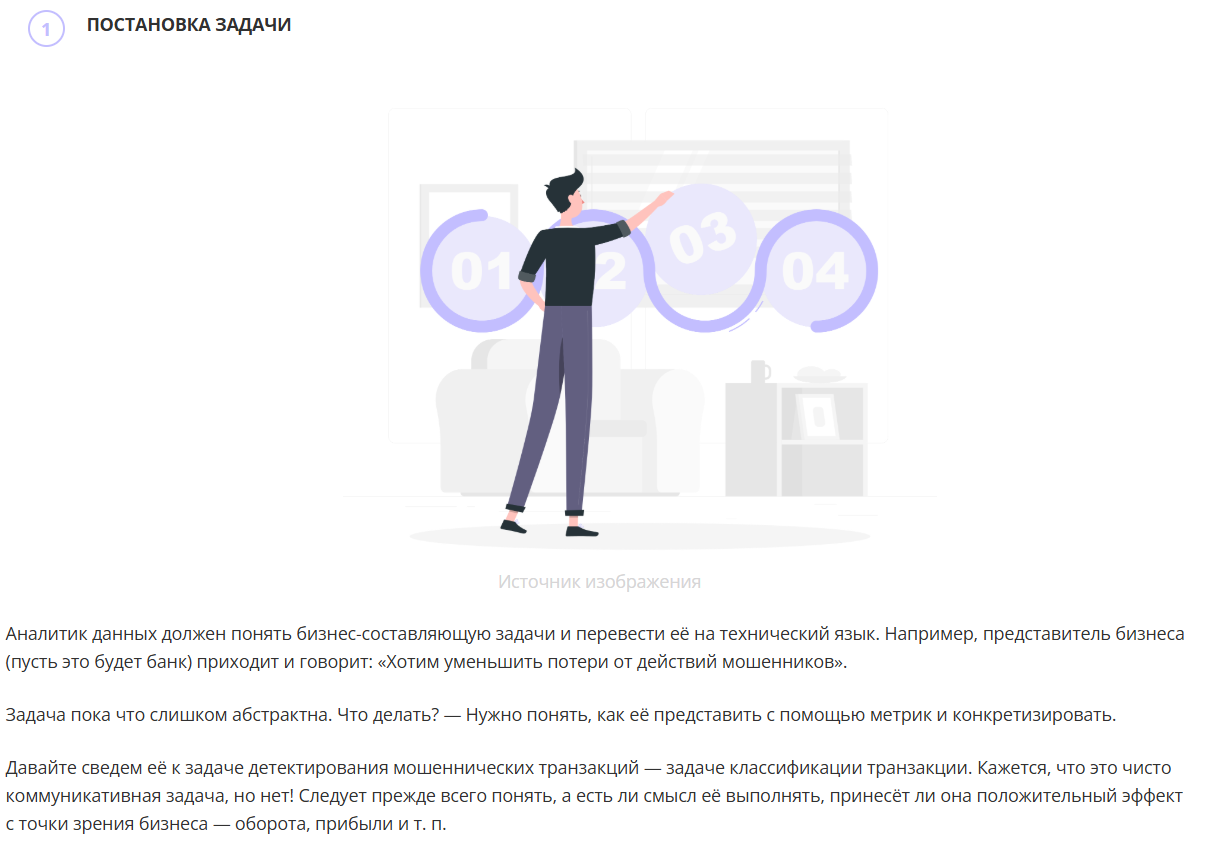

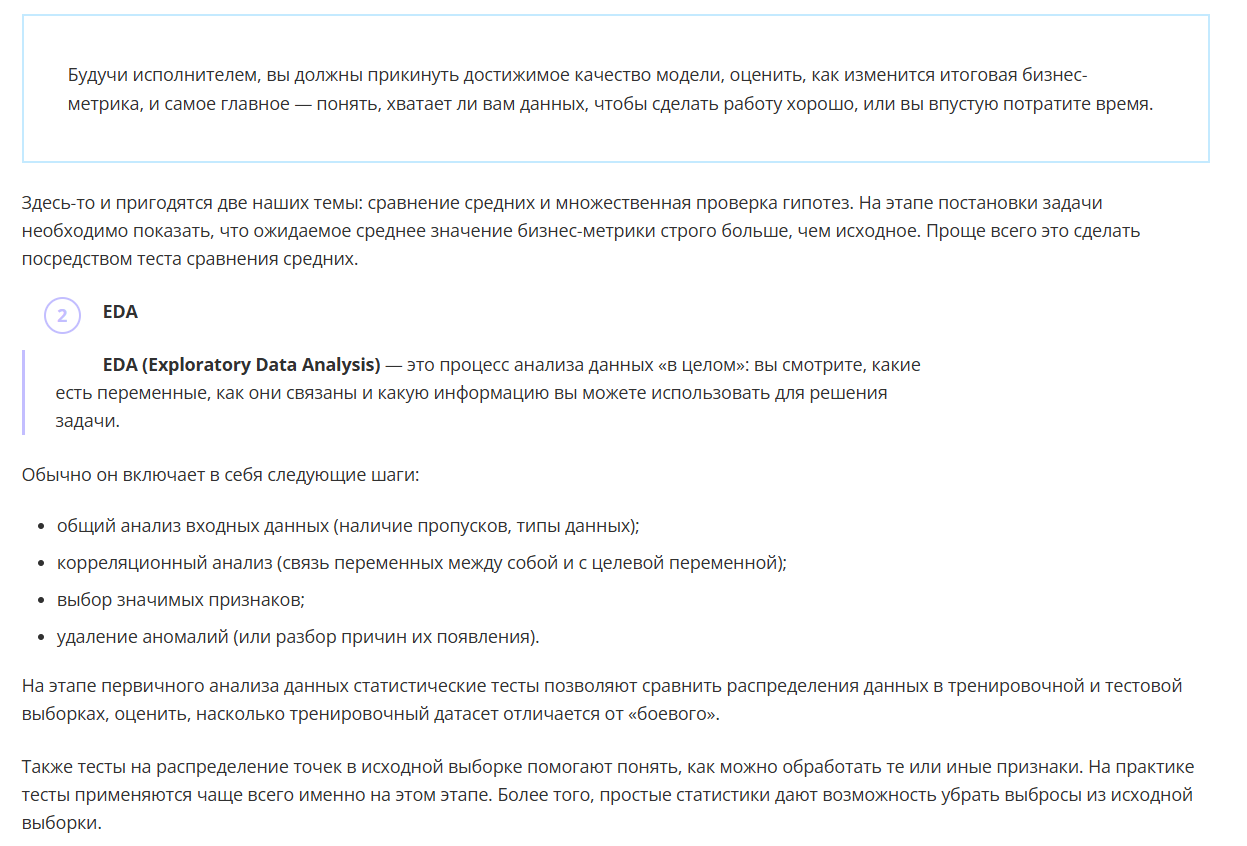

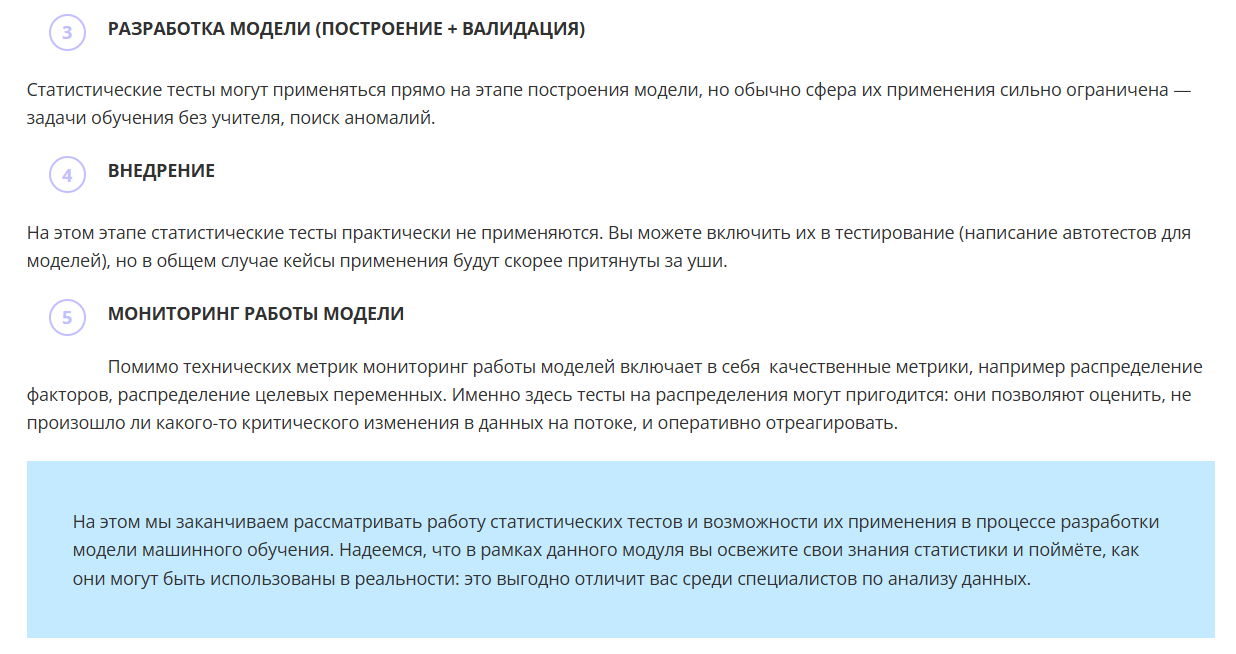

# 4. Тесты на среднее и доли

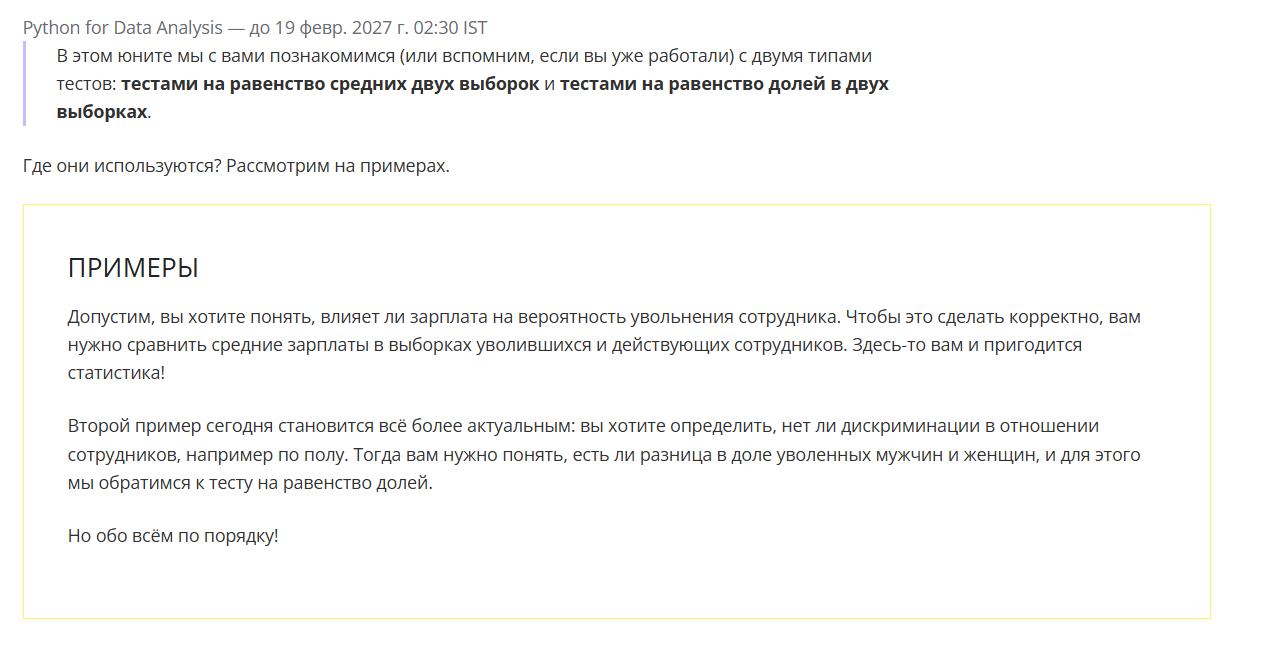

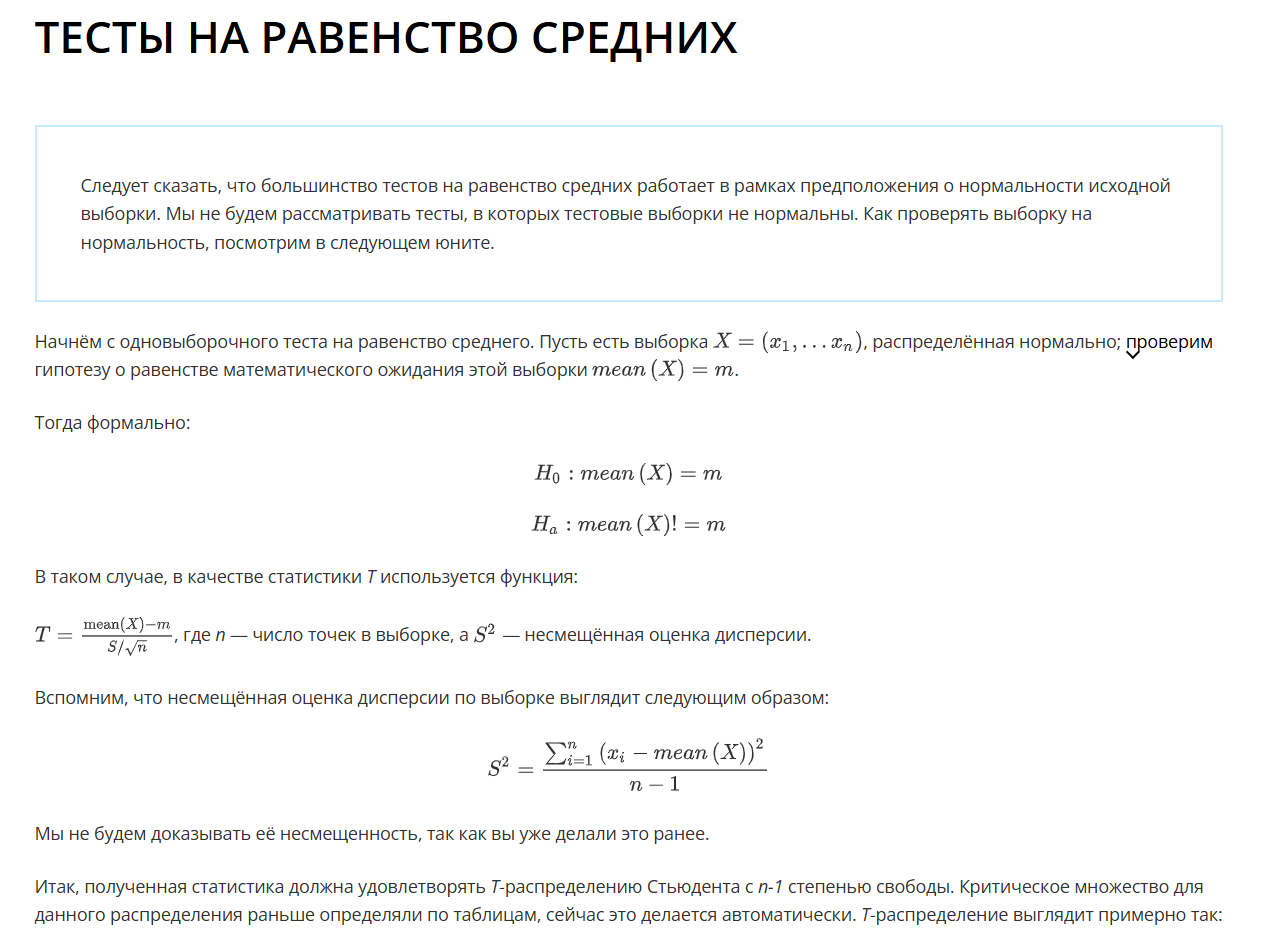

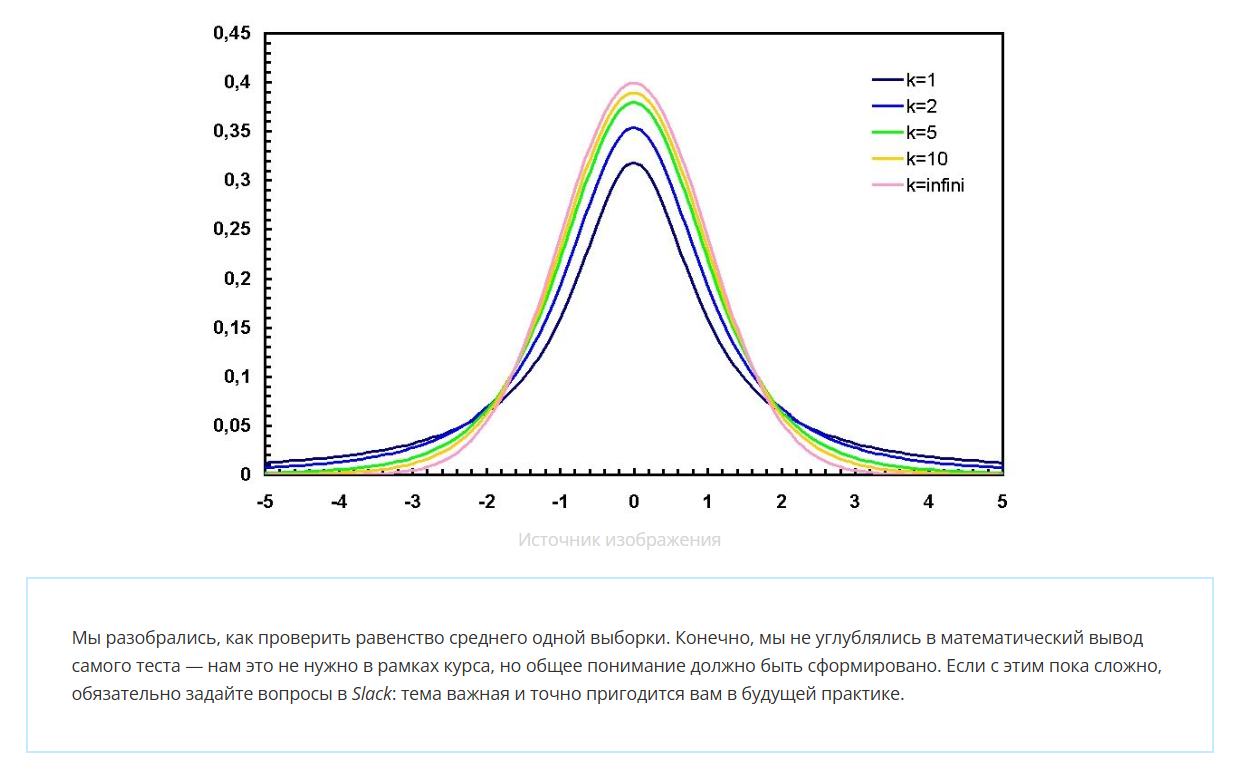

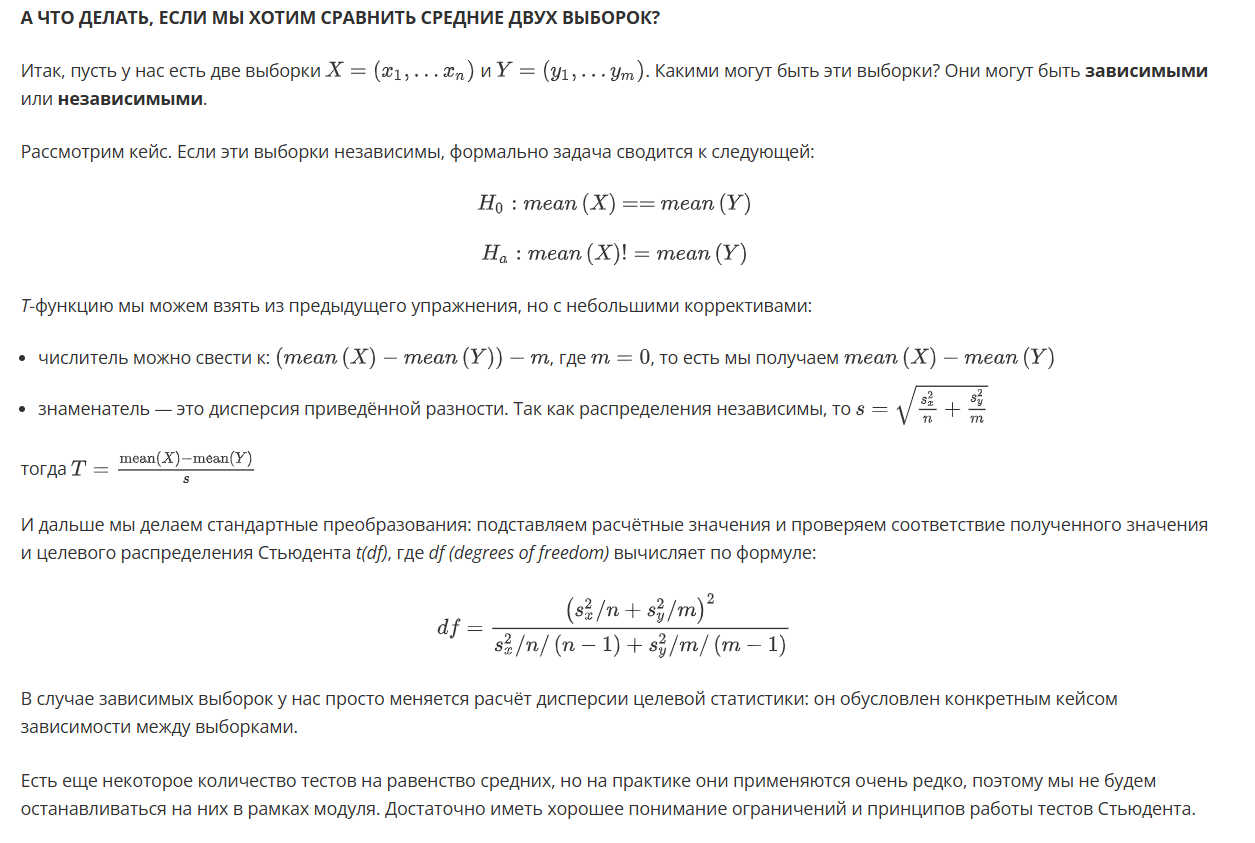

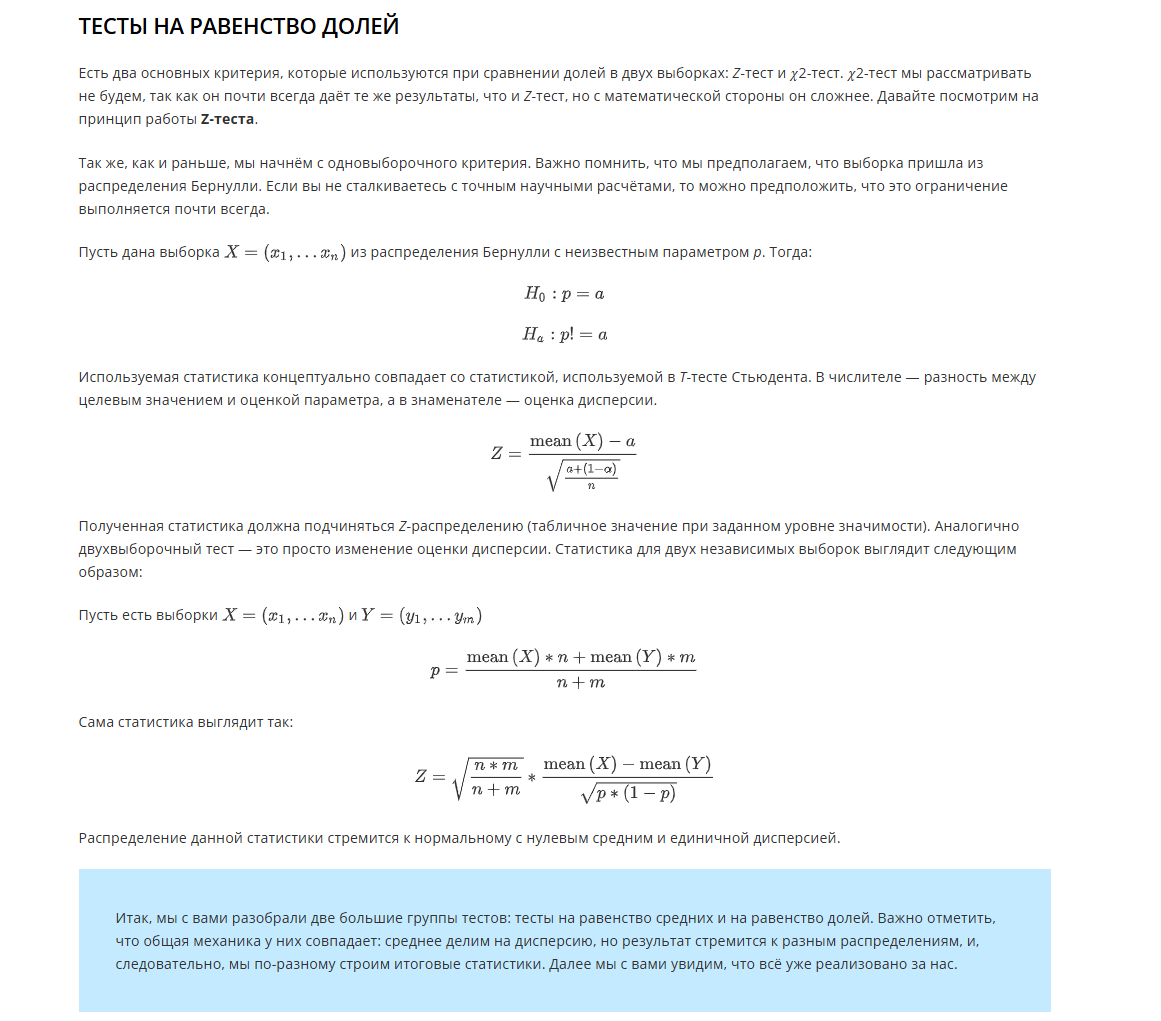

#  5. Тесты на среднее и доли. Практика

Потренируемся проводить статистические тесты с помощью SciPy. 

Как всегда, сначала импортируем необходимые пакеты:

In [1]:
import numpy as np
from scipy import stats

### Начнём с одновыборочных тестов

Помним, что данные должны приходить из нормального распределения. Сгенерируем множество точек из нормального распределения (для воспроизводимости зафиксируем random state) со средним, равным 5, и стандартным отклонением, равным 2.

In [2]:
np.random.seed(13)
random_normal = np.random.normal(5, 2, 100)
random_bin = np.random.choice([0, 1], size=(100,), p=[0.8, 0.2])

Проверим гипотезу, что среднее выборки, сгенерированной из нормального распределения, равно 0:

In [3]:
stats.ttest_1samp(random_normal, 0.0)

TtestResult(statistic=np.float64(27.315846581411247), pvalue=np.float64(6.762242033211871e-48), df=np.int64(99))

По результату мы видим, что p_value= 6.762242033211871e-48, соответственно, гипотеза о равенстве среднего нулю отвергается на уровне значимости 0.01 (вообще говоря, почти на любом уровне значимости).

Теперь проверим против 5.0:

In [4]:
stats.ttest_1samp(random_normal, 5.0)

TtestResult(statistic=np.float64(0.6236095710595042), pvalue=np.float64(0.5343182132984923), df=np.int64(99))

Мы видим, что гипотеза о равенстве 5 принимается с p_value=0.53.

Проведём тест на равенство доли единиц во второй выборке 0.5:

In [5]:
stats.binomtest(k=sum(random_bin), n=(len(random_bin) - sum(random_bin)), p=0.5)

BinomTestResult(k=20, n=80, alternative='two-sided', statistic=0.25, pvalue=8.580559867049611e-06)

Заметим, что x = [число позитивных действий, число фейлов]. Видим, что гипотеза отвергается практически на любом уровне значимости с p_value=1.115908905725195e-09.

In [6]:
stats.binomtest(k=sum(random_bin), n=(len(random_bin) - sum(random_bin)), p=0.2)

BinomTestResult(k=20, n=80, alternative='two-sided', statistic=0.25, pvalue=0.26401278555340046)

Гипотеза не отвергается.

### А теперь — двухвыборочный тест!

Мы увидели, что проводить статистический тест со SciPy просто! Давайте теперь проделаем то же самое со множественной проверкой гипотез.

Сгенерируем множества точек:

In [18]:
random_normal_5 = np.random.normal(5, 2, 100)


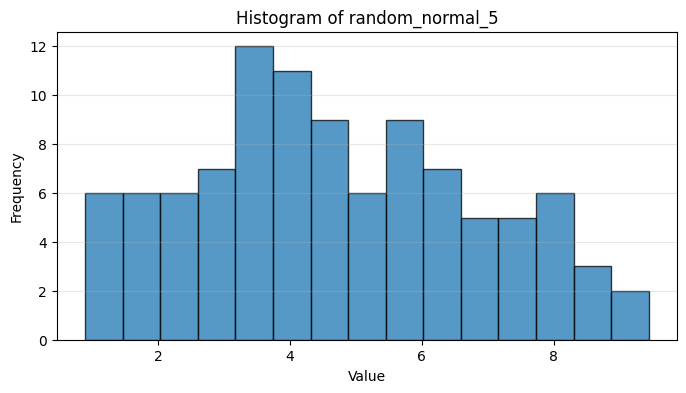

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(random_normal_5, bins=15, edgecolor="black", alpha=0.75)
plt.title("Histogram of random_normal_5")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [20]:
random_normal_false = np.random.normal(7, 2, 100)

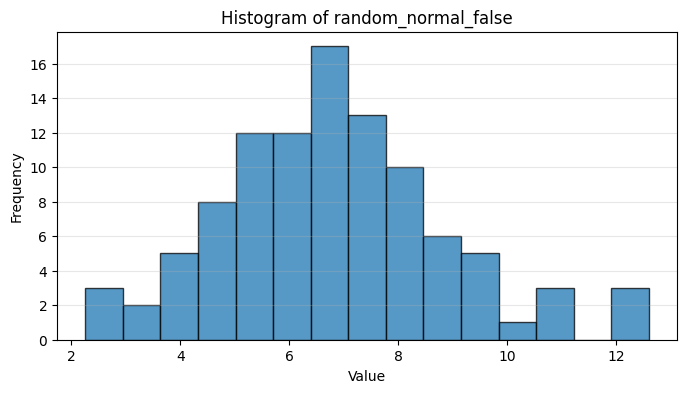

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(random_normal_false, bins=15, edgecolor="black", alpha=0.75)
plt.title("Histogram of random_normal_false")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

Проверим двухвыборочными тестами:

In [22]:
stats.ttest_ind(random_normal_5, random_normal)


TtestResult(statistic=np.float64(-1.5223357452711808), pvalue=np.float64(0.1295204348393076), df=np.float64(198.0))

In [23]:
stats.ttest_ind(random_normal_false, random_normal)

TtestResult(statistic=np.float64(6.167385250060292), pvalue=np.float64(3.834279968355439e-09), df=np.float64(198.0))

Видим, что в первом случае нулевая гипотеза не отвергается, а во втором — отвергается. Что ж, мы молодцы, и самое время перейти к задачам, не так ли?

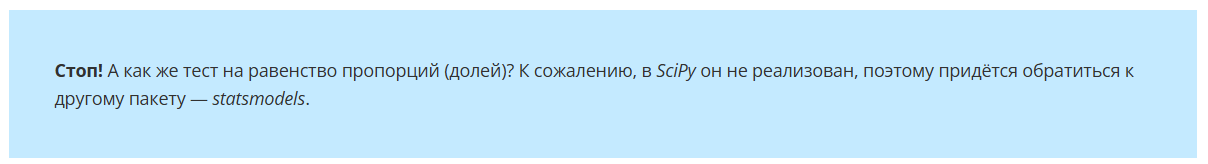

Импортируем его:

In [24]:
from statsmodels.stats.proportion import proportions_ztest

И снова сгенерируем бинарные выборки:

In [25]:
random_bin_2 = np.random.choice([0, 1], size=(100,), p=[0.8, 0.2])

In [26]:
random_bin_false = np.random.choice([0, 1], size=(100,), p=[0.6, 0.4])

Посмотрим на результат применения теста:

In [27]:
proportions_ztest(count=[sum(random_bin), sum(random_bin_2)], nobs=[len(random_bin), len(random_bin_2)])

(np.float64(0.0), np.float64(1.0))

In [28]:
proportions_ztest(count=[sum(random_bin), sum(random_bin_false)], nobs=[len(random_bin), len(random_bin_false)])

(np.float64(-3.5011625591278293), np.float64(0.00046323319060856513))

Первое число — значение статистики, второе — p_value. Видим, что результаты совпадают с ожидаемыми.

Обратим внимание, что в сам тест мы передаём не выборки, а только число положительных событий и общее число событий.

# 6. Тесты на нормальность

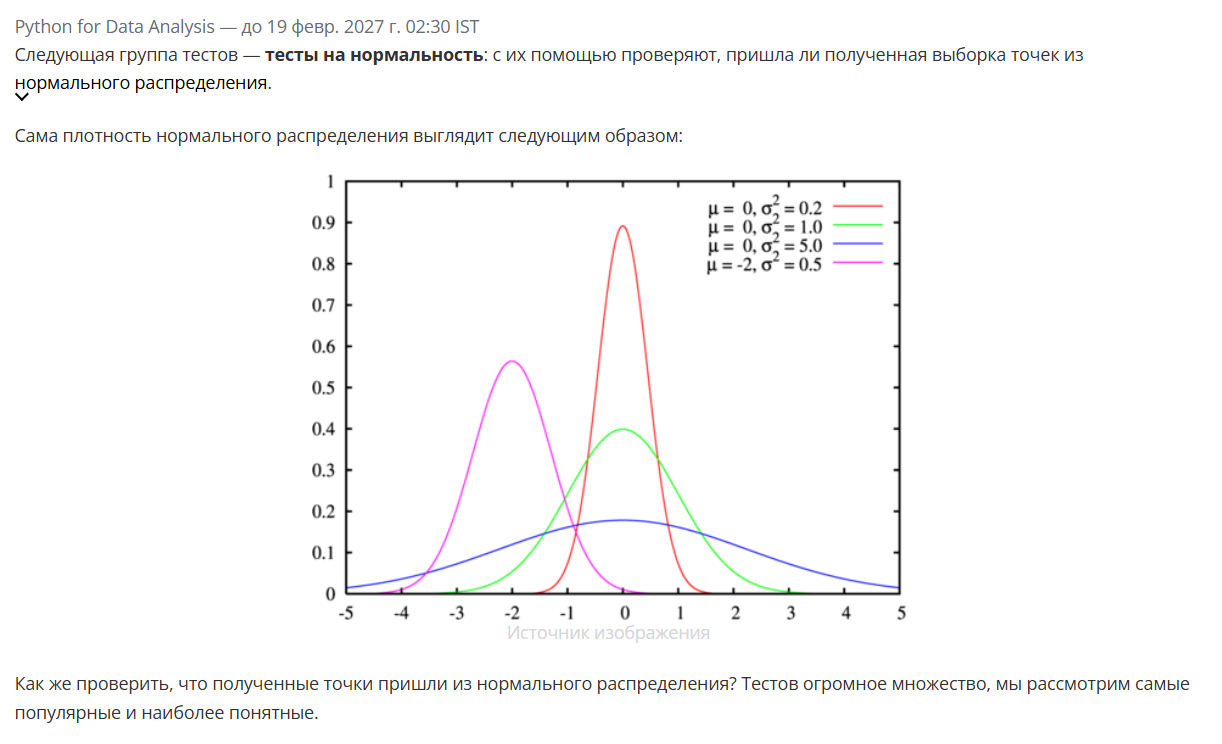

### Критерий Шапиро-Уилка

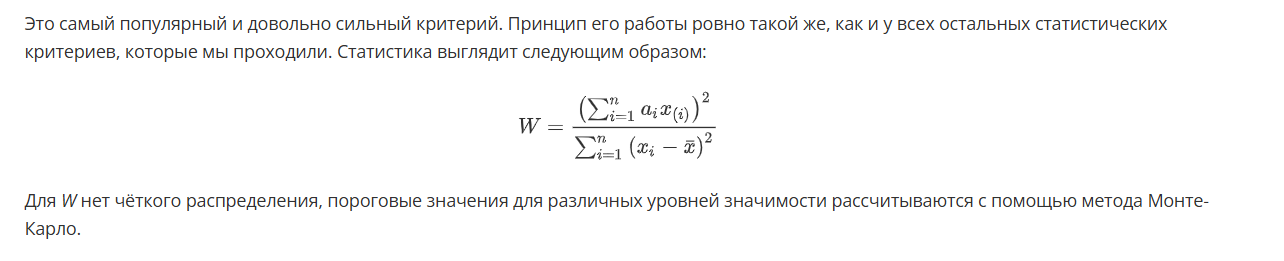

### Критерий Колмогорова-Смирнова

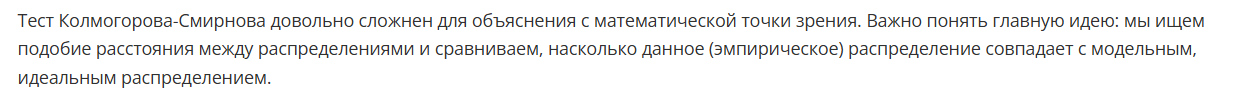

### Критерий асимметрии и эксцесса

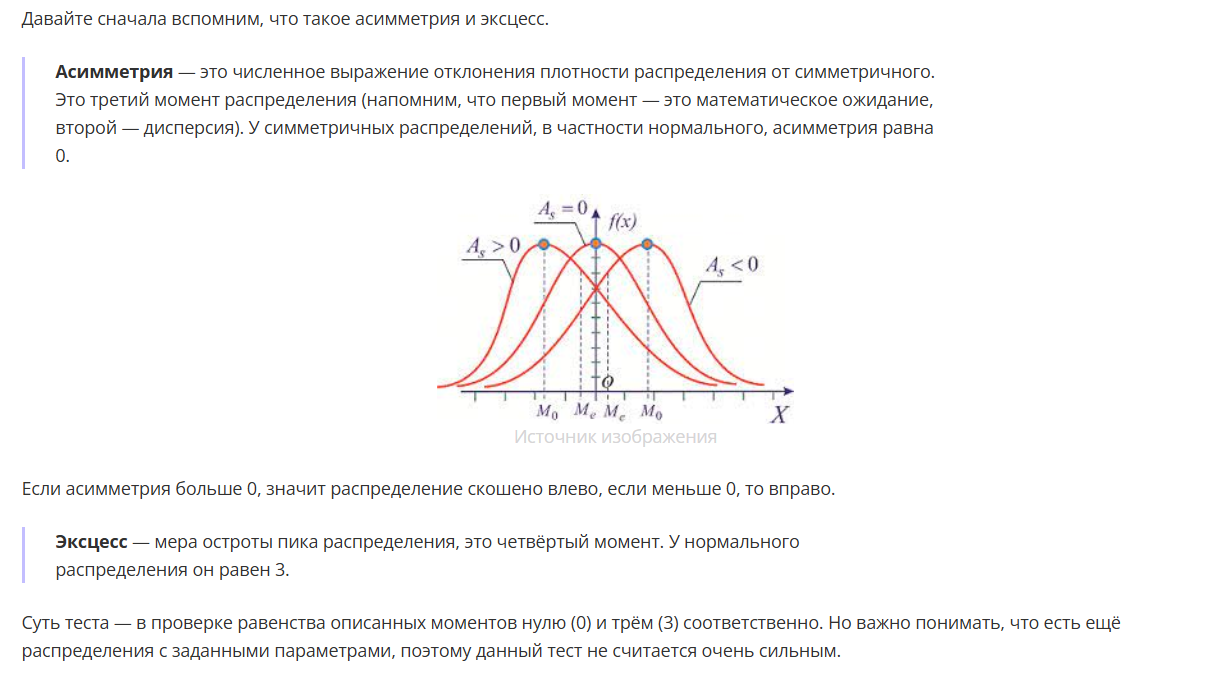

# 7. Тесты на нормальность. Практика

Cамое время попрактиковаться! Готовы?

Импортируем необходимые библиотеки и сгенерируем набор точек из нормального распределения.

In [33]:
import numpy as np
from scipy import stats

np.random.seed(13)
random_normal = np.random.normal(5, 2, 100)
random_uniform = np.random.uniform(0, 1, 100)

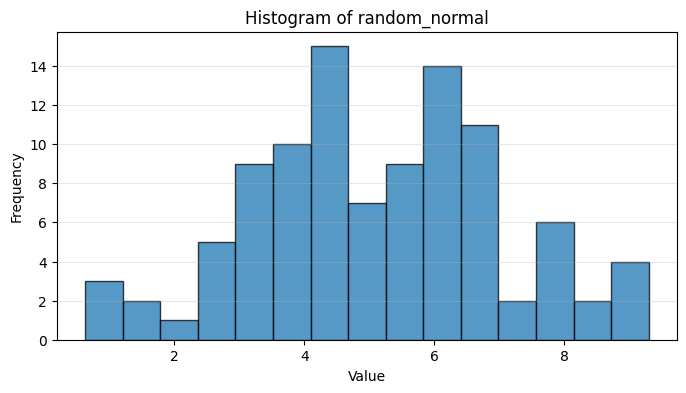

In [34]:
plt.figure(figsize=(8, 4))
plt.hist(random_normal, bins=15, edgecolor="black", alpha=0.75)
plt.title("Histogram of random_normal")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

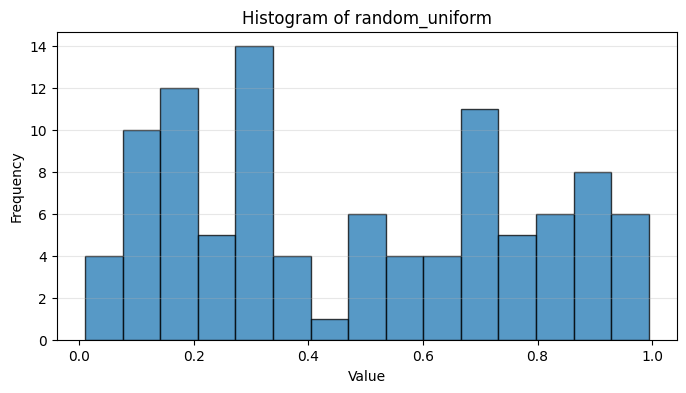

In [35]:
plt.figure(figsize=(8, 4))
plt.hist(random_uniform, bins=15, edgecolor="black", alpha=0.75)
plt.title("Histogram of random_uniform")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(axis="y", alpha=0.3)
plt.show()

Проведём тест на нормальность сгенерированных распределений:

In [36]:
stats.shapiro(random_normal)

ShapiroResult(statistic=np.float64(0.9897643468746817), pvalue=np.float64(0.6455599791405382))

In [37]:
stats.shapiro(random_uniform)

ShapiroResult(statistic=np.float64(0.9223205486897722), pvalue=np.float64(1.8727311444297305e-05))

Видим, что во втором случае нулевая гипотеза (нормальность распределения, из которого приходят точки) отвергается практически на любом уровне значимости.

В первом случае распределение нормальное. Для теста Колмогорова-Смирнова необходимо передавать распределение, относительно которого происходит сравнение. Давайте попробуем:

In [39]:
stats.kstest(random_normal, 'norm')

KstestResult(statistic=np.float64(0.933371471007256), pvalue=np.float64(4.646377515900967e-118), statistic_location=np.float64(2.476788109361862), statistic_sign=np.int8(-1))

In [40]:
stats.kstest(random_uniform, 'norm')

KstestResult(statistic=np.float64(0.5039276991503323), pvalue=np.float64(4.9262358819103416e-24), statistic_location=np.float64(0.00984544079968852), statistic_sign=np.int8(-1))

Мы видим, что в обоих случаях гипотеза о нормальности распределения отвергается. Почему? Потому что происходит сравнение с нормальным распределением со средним 0 и дисперсией 1. Проверим это, нормализовав входное множество точек.

In [41]:
stats.kstest((random_normal - np.mean(random_normal)) / np.std(random_normal), 'norm')

KstestResult(statistic=np.float64(0.06562034353090856), pvalue=np.float64(0.7572142037683822), statistic_location=np.float64(-0.40053934145643744), statistic_sign=np.int8(1))

Мы получили ожидаемый результат. Теперь ваша очередь!

Задание 7.1

Чему равно p_value проверки на нормальность данных, сгенерированных следующим образом, тестом Шапиро-Уилка? Ответ округлите до второго знака после запятой.

In [42]:
np.random.seed(2)
random_normal = np.random.normal(2, 4, 10)

In [44]:
shapiro_stat, p_value = stats.shapiro(random_normal)
round(p_value, 2)

np.float64(0.73)

Задание 7.2
 
Чему равно p_value проверки на нормальность данных, сгенерированных следующим образом, тестом Колмогорова-Смирнова без нормализации? Ответ округлите до второго знака после запятой.

In [45]:
np.random.seed(2)
random_normal = np.random.normal(2, 4, 10)

In [47]:
ks_stat, p_value = stats.kstest(random_normal, 'norm')
round(p_value, 2)

np.float64(0.01)

Задание 7.3
 
Чему равно p_value проверки на нормальность данных, сгенерированных следующим образом, тестом Колмогорова-Смирнова с нормализацией? Ответ округлите до второго знака после запятой.

In [48]:
np.random.seed(2)
random_normal = np.random.normal(2, 4, 10)


In [ ]:
ks_stat, p_value = stats.kstest((random_normal - np.mean(random_normal)) / np.std(random_normal), 'norm')
round(p_value, 2)